# 3. SARIMAX Model

In this notebook, we load our preprocessed time-series data and train **cluster-specific** SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous factors) models. SARIMAX bridges the gap between our previous approaches: it leverages historical lags and error terms to capture sudden stochastic spikes (like Linear Regression) while simultaneously modeling strict seasonal cycles (like Prophet), making it a highly robust algorithm for our behavioral clusters.

**Model Components:**
* **AR(p):** Autoregressive lags (momentum from past values).
* **I(d):** Differencing to achieve time-series stationarity.
* **MA(q):** Moving Average of past forecast errors.
* **S(P, D, Q, s):** Seasonal lags to capture daily cycles.
* **X:** Exogenous variables (e.g., Temperature, Holidays).

## 1. Imports and Data Loading
We import `pandas` for data handling, `statsmodels` for our core SARIMAX algorithm, and `scikit-learn` strictly for evaluating our business metrics (MAPE and WMAPE). We then load our highly compressed Parquet data alongside our predefined client clusters.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
import gc

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

warnings.filterwarnings("ignore")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11})

# ---------------------------------------------------------
# Load only the columns we actually need (saves ~60% RAM vs loading all)
# ---------------------------------------------------------
print("Loading processed data...")
needed_cols = ['Date', 'ClientID', 'Consumption', 'Cluster',
               'Weekday', 'Is_Weekend', 'Is_Holiday',
               'HDH', 'CDH', 'HDH_lag24h', 'CDH_lag24h',
               'HDH_anomaly', 'CDH_anomaly']

df_full = pd.read_parquet('../Datasets/processed_electricity_data.parquet')
available_cols = [c for c in needed_cols if c in df_full.columns]
df_long = df_full[available_cols].copy()
del df_full
gc.collect()

cluster_map = df_long[['ClientID', 'Cluster']].drop_duplicates()
print(f"Loaded {len(df_long):,} rows | {df_long['ClientID'].nunique()} clients")

## 2. Cluster-Level Seasonality Analysis (ACF & PACF)

To determine the optimal parameters $(p, d, q)$ and seasonal parameters $(P, D, Q, s)$ for our SARIMAX models, we must analyze the stationarity and autocorrelation of the time series. 

Rather than analyzing a random individual client (which contains idiosyncratic noise), we aggregate the consumption to create a **Cluster Average Profile**. 

**Note: The following visual Exploratory Data Analysis (EDA) and seasonal decomposition is provided as an illustrative example strictly for Cluster 0.** We decompose the time series to observe its trend and seasonality. We expect to see a strong daily seasonal cycle.

In [ ]:
# We analyze the average behavior of a specific cluster
print("Aggregating data for Cluster 0 (Illustrative EDA)...")

# Select only the column we need for EDA
cluster_series = (
    df_long.loc[df_long['Cluster'] == 0, ['Date', 'Consumption']]
    .groupby('Date')['Consumption'].mean()
    .to_frame()
    .sort_index()
    .asfreq("15min")
)
cluster_series['Consumption'] = cluster_series['Consumption'].ffill()

y = cluster_series['Consumption']

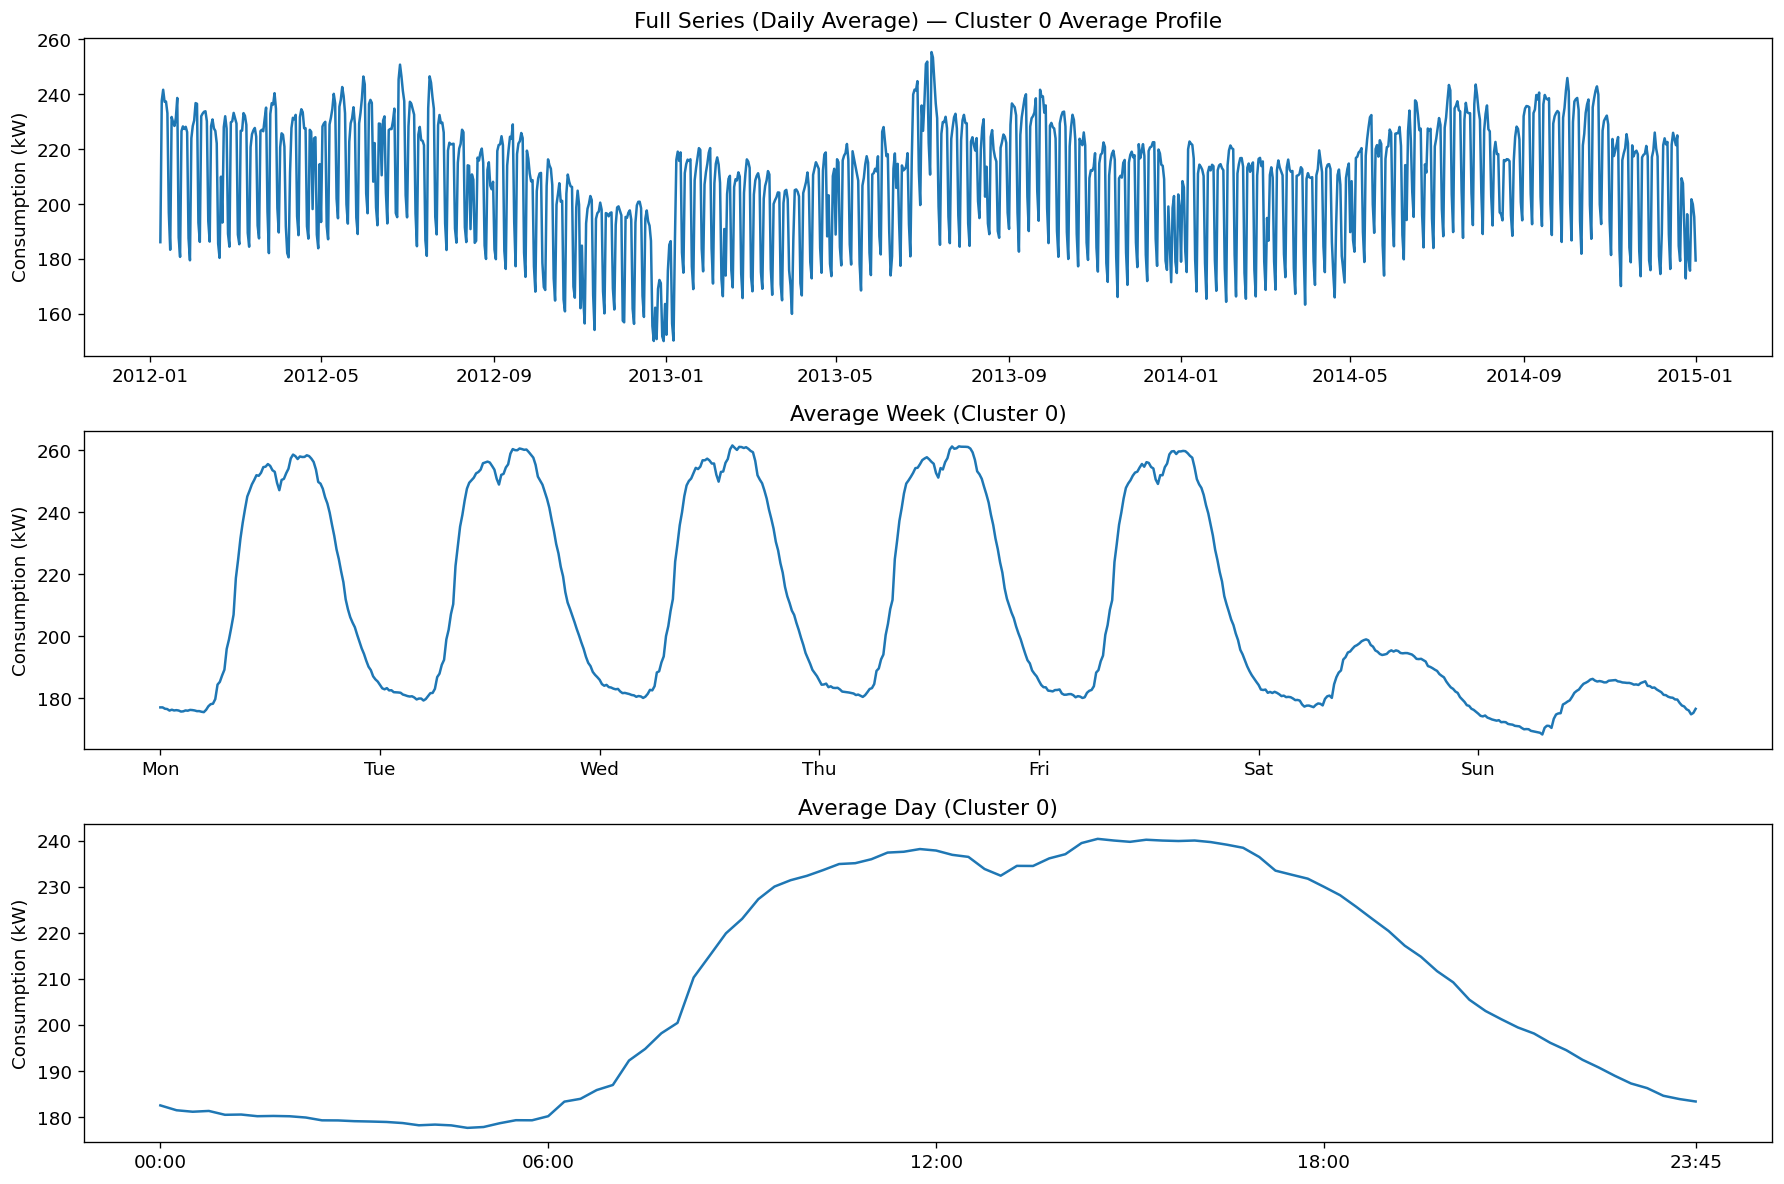

In [3]:
# Extract time components for plotting
y_with_features = y.to_frame()
y_with_features['dayofweek']   = y.index.dayofweek
y_with_features['time_of_day'] = y.index.hour * 4 + y.index.minute // 15

average_week = y_with_features.groupby(['dayofweek', 'time_of_day'])['Consumption'].mean()
average_day  = y_with_features.groupby('time_of_day')['Consumption'].mean()

fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Plot 1: Daily Average over time
axes[0].plot(y.resample('D').mean())
axes[0].set_title("Full Series (Daily Average) — Cluster 0 Average Profile")
axes[0].set_ylabel("Consumption (kW)")

# Plot 2: Average Week Shape
axes[1].plot(average_week.values)
axes[1].set_title("Average Week (Cluster 0)")
axes[1].set_xticks([i * 96 for i in range(7)])
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[1].set_ylabel("Consumption (kW)")

# Plot 3: Average Day Shape
axes[2].plot(average_day.values)
axes[2].set_title("Average Day (Cluster 0)")
axes[2].set_xticks([0, 24, 48, 72, 95])
axes[2].set_xticklabels(['00:00', '06:00', '12:00', '18:00', '23:45'])
axes[2].set_ylabel("Consumption (kW)")

plt.tight_layout()
plt.show()

In [4]:
print("Calculating Seasonal Decomposition...")

# The entire dataset is too massive to plot at 15-minute resolution (it creates a solid blue block).
# We slice a 2-week window (14 days * 96 steps = 1344 points) to actually visualize the seasonal waves.
y_zoomed = y.dropna().iloc[:14 * 96]

# Decompose the zoomed-in slice
decomposition = seasonal_decompose(y_zoomed, model="additive", period=96)

# Plot with a customized, larger figure size to make the subplots readable
fig = decomposition.plot()
fig.set_size_inches(14, 8) # Allarga il grafico per far respirare le onde

plt.suptitle("Seasonal Decomposition (2-Week Zoom, period=96) — Cluster 0", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Calculating Seasonal Decomposition...


NameError: name 'seasonal_decompose' is not defined

In [ ]:
def adf_test(series, name="Series"):
    # Perform Augmented Dickey-Fuller test to check if the mean drifts over time
    result = adfuller(series.dropna())
    print(f"ADF Test: {name}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    
    # A p-value < 0.05 indicates the series is stationary (no differencing needed)
    if result[1] < 0.05:
        print("  Result        : Stationary (d=0)")
    else:
        print("  Result        : Non-stationary — consider differencing (d=1)")

adf_test(y, "Cluster 0 Average Consumption")

In [ ]:
# These plots tell us the AR (p) and MA (q) parameters
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(y.dropna(), lags=100, ax=axes[0], title="Autocorrelation (ACF) - helps find MA(q)")
plot_pacf(y.dropna(), lags=100, ax=axes[1], title="Partial Autocorrelation (PACF) - helps find AR(p)")
plt.tight_layout()
plt.show()

### 2.1 Parameter Identification for All Clusters (Hourly Resampled)

While the high-resolution 15-minute data is excellent for capturing immediate spikes, training a SARIMAX model with a seasonal periodicity of $s=96$ is computationally prohibitive and often leads to non-convergence. 

To ensure stability and scalability, we will train our SARIMAX models on **hourly aggregated data** ($s=24$). Therefore, to find the correct AR ($p$) and MA ($q$) parameters for each of our 5 cluster models, we must compute the Autocorrelation (ACF) and Partial Autocorrelation (PACF) on the hourly-resampled cluster averages.

In [ ]:
def auto_estimate_pq(series, nlags=20, alpha=0.05, max_pq=3):
    """
    Automatically estimates AR (p) and MA (q) parameters by finding 
    the first lag where the correlation falls inside the 95% confidence interval.
    Includes a 'max_pq' cap to prevent computationally impossible models.
    """
    from statsmodels.tsa.stattools import acf, pacf
    
    # Calculate PACF to find 'p'
    pacf_vals, pacf_confint = pacf(series, nlags=nlags, alpha=alpha)
    pacf_threshold = pacf_confint[:, 1] - pacf_vals
    p = 0
    for i in range(1, nlags + 1):
        if abs(pacf_vals[i]) > pacf_threshold[i]:
            p = i
        else:
            break
            
    # Calculate ACF to find 'q'
    acf_vals, acf_confint = acf(series, nlags=nlags, alpha=alpha)
    acf_threshold = acf_confint[:, 1] - acf_vals
    q = 0
    for i in range(1, nlags + 1):
        if abs(acf_vals[i]) > acf_threshold[i]:
            q = i
        else:
            break
            
    p = min(p, max_pq)
    q = min(q, max_pq)
            
    return p, q

print("Automating (p, d, q) extraction for all clusters (Hourly Resolution)...\n")
unique_clusters = sorted(df_long['Cluster'].dropna().unique())

# We will store the optimal parameters in a dictionary to use them automatically in the training loop
cluster_params = {}

for cluster_id in unique_clusters:
    # 1. Filter and Aggregate
    df_c = df_long[df_long['Cluster'] == cluster_id]
    cluster_series = df_c.groupby('Date')['Consumption'].mean().to_frame()
    cluster_series = cluster_series.sort_index()
    
    # 2. Resample to HOURLY frequency
    cluster_hourly = cluster_series.resample('h').mean().ffill()
    y_hourly = cluster_hourly['Consumption'].dropna()
    
    # 3. Check Stationarity (d parameter)
    result = adfuller(y_hourly)
    d = 0 if result[1] < 0.05 else 1
    
    # 4. Auto-estimate p and q
    p, q = auto_estimate_pq(y_hourly)
    
    # Store parameters
    cluster_params[cluster_id] = {'p': p, 'd': d, 'q': q}
    
    is_stat_text = "Stationary" if d == 0 else "Non-Stationary"
    print(f"Cluster {cluster_id} | {is_stat_text} -> Extracted Params: AR(p)={p}, I(d)={d}, MA(q)={q}")

print("\nParameter extraction complete! Dictionary 'cluster_params' is ready for training.")

### Model Fitting

Parameters selected manually from ACF/PACF plots. `auto_arima` was infeasible at 15-min resolution (s=96) due to memory and runtime constraints. Each of the 30 clients gets its own model fitted on a 4-week training window.

In [ ]:
SPLIT_DATE = '2014-01-01'

# Fixed seasonal parameters (Hourly frequency -> s=24)
P, D, Q, s = 1, 0, 1, 24 

cluster_models = {}
cluster_forecasts = {}

print(f"--- TRAINING 5 CLUSTER-LEVEL SARIMAX MODELS ---")
print(f"Train Period: Up to {SPLIT_DATE} | Test Period: 2014\n")

# ---------------------------------------------------------
# Exogenous variables: calendar + weather (no Temp_National_Avg — multicollinear)
# ---------------------------------------------------------
exog_cols = ['Weekday', 'Is_Weekend', 'Is_Holiday', 'HDH', 'CDH',
             'HDH_lag24h', 'CDH_lag24h',
             'HDH_anomaly', 'CDH_anomaly']

valid_exog = [col for col in exog_cols if col in df_long.columns]

for cluster_id in unique_clusters:
    p = cluster_params[cluster_id]['p']
    d = cluster_params[cluster_id]['d']
    q = cluster_params[cluster_id]['q']
    
    print(f"Training Model for Cluster {cluster_id} [SARIMAX({p},{d},{q})x({P},{D},{Q},{s})] ...")
    
    # ---------------------------------------------------------
    # Select ONLY the columns we need (not the full df_long copy)
    # ---------------------------------------------------------
    mask = df_long['Cluster'] == cluster_id
    cols_needed = ['Consumption'] + valid_exog
    cluster_hourly = (
        df_long.loc[mask, ['Date'] + cols_needed]
        .set_index('Date')
        .sort_index()
        .astype(float)
        .resample('h')
        .mean()
        .ffill()
    )
       
    # ---------------------------------------------------------
    # Train/Test Split (Chronological)
    # ---------------------------------------------------------
    train_data = cluster_hourly[cluster_hourly.index < SPLIT_DATE]
    test_data  = cluster_hourly[cluster_hourly.index >= SPLIT_DATE]
    
    y_train    = train_data['Consumption']
    exog_train = train_data[valid_exog]
    exog_test  = test_data[valid_exog]
    
    # ---------------------------------------------------------
    # Fit SARIMAX (maxiter=200, method=powell for reliable convergence)
    # ---------------------------------------------------------
    model = SARIMAX(
        y_train, 
        exog=exog_train,
        order=(p, d, q), 
        seasonal_order=(P, D, Q, s),
        enforce_stationarity=False, 
        enforce_invertibility=False
    )
    fitted_model = model.fit(disp=False, maxiter=200, method='powell')
    cluster_models[cluster_id] = fitted_model
    
    # ---------------------------------------------------------
    # Forecast entire 2014, resample back to 15-min for client mapping
    # ---------------------------------------------------------
    forecast = fitted_model.forecast(steps=len(test_data), exog=exog_test)
    forecast = np.maximum(forecast, 0)
    
    forecast_15m = forecast.resample('15min').ffill()
    cluster_forecasts[cluster_id] = forecast_15m
    
    # Free intermediate objects
    del cluster_hourly, train_data, test_data, model
    gc.collect()
    
    print(f" -> Cluster {cluster_id} complete.\n")

print("Training phase completed successfully!")

In [ ]:
# CLIENT-LEVEL EVALUATION & METRICS (2014)
print("\n--- EVALUATING ON ALL CLIENTS (2014 TEST SET) ---")

client_results = []
all_clients = df_long['ClientID'].unique()

# Pre-calculate the average train consumption for each cluster to speed up the loop
cluster_train_means = {}
for cid in unique_clusters:
    c_data = df_long[(df_long['Cluster'] == cid) & (df_long['Date'] < SPLIT_DATE)]
    cluster_train_means[cid] = c_data['Consumption'].mean()

for client_id in tqdm(all_clients, desc="Evaluating Clients"):
    df_client = df_long[df_long['ClientID'] == client_id].copy()
    df_client = df_client.set_index('Date').sort_index()
    
    cluster_id = df_client['Cluster'].iloc[0]
    
    train_client = df_client[df_client.index < SPLIT_DATE]['Consumption']
    test_client  = df_client[df_client.index >= SPLIT_DATE]['Consumption']
    
    if len(train_client) == 0 or len(test_client) == 0:
        continue # Skip if client has missing data
        
    # 1. Scaling factor: Client's historical size vs Cluster's historical size
    client_scale = train_client.mean() / cluster_train_means[cluster_id]
    
    # 2. Get the cluster's base forecast and align it to the client's test dates
    base_forecast = cluster_forecasts[cluster_id]
    aligned_forecast = base_forecast.reindex(test_client.index).ffill()
    
    # 3. Un-scale the forecast to match client's precise kW volume
    y_pred = (aligned_forecast * client_scale).values
    y_true = test_client.values
    
    # --- CALCULATE METRICS ---
    nz = y_true > 0.1
    if nz.sum() > 0:
        mape = np.mean(np.abs((y_true[nz] - y_pred[nz]) / y_true[nz])) * 100
    else:
        mape = np.nan
        
    abs_error_sum = np.sum(np.abs(y_true - y_pred))
    actual_sum = np.sum(y_true)
    
    client_results.append({
        'ClientID': client_id,
        'MAPE': mape,
        'Abs_Error_Sum': abs_error_sum,
        'Actual_Sum': actual_sum
    })

# --- GLOBAL RESULTS ---
print("\n--- SARIMAX BENCHMARK RESULTS ---")
valid_mapes = [res['MAPE'] for res in client_results if not np.isnan(res['MAPE'])]
print(f"Global Average MAPE: {np.mean(valid_mapes):.2f}%")

# Calculate Global WMAPE by aggregating all absolute errors and actuals
total_abs_error = sum(res['Abs_Error_Sum'] for res in client_results)
total_actual = sum(res['Actual_Sum'] for res in client_results)
global_wmape = (total_abs_error / total_actual) * 100 if total_actual > 0 else 0.0

print(f"Global WMAPE: {global_wmape:.2f}%")

# --- PERFORMANCE BREAKDOWN BY CLUSTER ---
sarimax_results_df = pd.DataFrame(client_results)
sarimax_results_df = sarimax_results_df.merge(cluster_map, on='ClientID')

print("\n--- SARIMAX PERFORMANCE BY CLUSTER ---\n")

# Aggregate the sums to compute true WMAPE per cluster, not just an average of averages
summary = sarimax_results_df.groupby('Cluster').agg(
    n_clients=('ClientID', 'count'),
    Average_MAPE=('MAPE', 'mean'),
    Total_Abs_Error=('Abs_Error_Sum', 'sum'),
    Total_Actual=('Actual_Sum', 'sum')
)

# Calculate Cluster WMAPE and clean up the dataframe
summary['WMAPE'] = (summary['Total_Abs_Error'] / summary['Total_Actual']) * 100
summary = summary.drop(columns=['Total_Abs_Error', 'Total_Actual']).round(2)

print(summary)

## 4. Forecasting Visualization
To visually validate our SARIMAX models, we plot the actual vs. predicted consumption for one representative client per cluster. 
We reconstruct the specific client's forecast by taking the pure behavioral pattern learned by the cluster's Prophet model and un-scaling it using the client's individual `StandardScaler`. We slice the plot to show only the **last 14 days** to ensure the daily seasonal curves are readable.

In [ ]:
# --- VISUALIZATION: ONE CLIENT PER CLUSTER (SARIMAX) ---
print("Generating validation plots for SARIMAX...")

# 1. Select one representative client for each cluster dynamically from the test set (2014)
df_test = df_long[df_long['Date'] >= SPLIT_DATE]
cluster_representatives = df_test.groupby('Cluster')['ClientID'].first().to_dict()

# 2. Setup the Matplotlib figure
fig, axes = plt.subplots(len(cluster_representatives), 1, figsize=(15, 5 * len(cluster_representatives)))

for idx, (cluster_id, client_id) in enumerate(sorted(cluster_representatives.items())):
    ax = axes[idx] if len(cluster_representatives) > 1 else axes

    # Extract test data for this specific client
    client_test_data = df_test[df_test['ClientID'] == client_id].copy()
    client_test_data = client_test_data.set_index('Date').sort_index()
    
    y_actual_kw = client_test_data['Consumption'].values
    dates = client_test_data.index

    # --- RECONSTRUCT FORECAST (SARIMAX LOGIC) ---
    # a. Get the client's historical mean from the training period
    client_train_mean = df_long[(df_long['ClientID'] == client_id) & (df_long['Date'] < SPLIT_DATE)]['Consumption'].mean()
    
    # b. Calculate Scaling Factor (Client Volume / Cluster Volume)
    # Note: cluster_train_means must be defined (it was in the evaluation block)
    client_scale = client_train_mean / cluster_train_means[cluster_id]

    # c. Map the cluster forecast to this client and scale it
    base_forecast = cluster_forecasts[cluster_id]
    aligned_forecast = base_forecast.reindex(client_test_data.index).ffill()
    y_pred_kw = (aligned_forecast * client_scale).values
    y_pred_kw = np.maximum(y_pred_kw, 0) # Floor to zero

    # Calculate individual Masked MAPE
    nz = y_actual_kw > 0.1
    if nz.sum() > 0:
        client_mape = np.mean(np.abs((y_actual_kw[nz] - y_pred_kw[nz]) / y_actual_kw[nz])) * 100
    else:
        client_mape = 0.0

    # VISUAL OPTIMIZATION: slice to plot only the last 2 weeks (1344 steps of 15-min)
    plot_slice = -1344 

    ax.plot(dates[plot_slice:], y_actual_kw[plot_slice:],
            label='Actual (Test 2014)', color='blue', alpha=0.5)
    ax.plot(dates[plot_slice:], y_pred_kw[plot_slice:],
            label='Predicted (SARIMAX Cluster Model)', color='red', linestyle='--', alpha=0.8)

    ax.set_title(f'Cluster {cluster_id} — Client {client_id} | Individual MAPE: {client_mape:.2f}%')
    ax.set_ylabel('Consumption (kW)')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.2)

# Global formatting
axes[-1].set_xlabel('Date')
plt.suptitle("SARIMAX: Out-of-Sample Forecast vs Actual (Last 2 Weeks of 2014)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns

# --- PREPARING DATA FOR TIME PERIOD ANALYSIS ---
print("Reconstructing full 2014 test set for Time Period Analysis...")

eval_list = []
df_test_all = df_long[df_long['Date'] >= SPLIT_DATE].copy()

# Per efficienza, calcoliamo le previsioni client-per-client e le accumuliamo
for client_id in tqdm(all_clients, desc="Processing Clients"):
    # 1. Get Actuals
    client_test = df_test_all[df_test_all['ClientID'] == client_id].copy()
    if client_test.empty: 
        continue
    
    raw_cluster_id = client_test['Cluster'].iloc[0]
    
    if pd.isna(raw_cluster_id):
        continue
        
    cluster_id = int(raw_cluster_id) # Forza a intero per sicurezza nel lookup del dizionario
    
    # 2. Get Client Scaling Factor
    client_train_data = df_long[(df_long['ClientID'] == client_id) & (df_long['Date'] < SPLIT_DATE)]
    
    if client_train_data.empty:
        continue
        
    client_train_mean = client_train_data['Consumption'].mean()
    
    # Verifica che il cluster esista nel nostro dizionario delle medie
    if cluster_id not in cluster_train_means:
        continue
        
    client_scale = client_train_mean / cluster_train_means[cluster_id]
    
    # 3. Align Cluster Forecast and Scale it
    if cluster_id not in cluster_forecasts:
        continue
        
    base_forecast = cluster_forecasts[cluster_id]
    
    # Reindex per allineare i timestamp del cliente alla previsione del cluster
    aligned_forecast = base_forecast.reindex(client_test['Date']).ffill().values
    
    y_pred_kw = np.maximum(aligned_forecast * client_scale, 0)
    
    # 4. Prepare temporary dataframe
    temp_df = pd.DataFrame({
        'Date': client_test['Date'].values,
        'Actual': client_test['Consumption'].values,
        'Predicted': y_pred_kw
    })
    eval_list.append(temp_df)

# Combine everything into one large evaluation dataframe
df_eval = pd.concat(eval_list, ignore_index=True)
del eval_list # Free memory

# --- DYNAMIC TIME PERIOD LABELS ---
print("Calculating periods and errors...")
_, bin_edges = pd.cut(df_eval['Date'], bins=4, retbins=True)
bin_edges = pd.to_datetime(bin_edges)
dynamic_labels = [f"{bin_edges[i].strftime('%b %d')} to {bin_edges[i+1].strftime('%b %d')}" for i in range(4)]

df_eval['Time_Period'] = pd.cut(df_eval['Date'], bins=4, labels=dynamic_labels)

# --- CALCULATE ERRORS ---
df_eval['Absolute_Error'] = np.abs(df_eval['Actual'] - df_eval['Predicted'])

# Calculate Masked APE (only where Actual > 0.1)
valid_mask = df_eval['Actual'] > 0.1
df_eval_valid = df_eval[valid_mask].copy()
df_eval_valid['APE'] = (df_eval_valid['Absolute_Error'] / df_eval_valid['Actual']) * 100

# 1. Print metrics by period
print("\n--- MAPE BY TIME PERIOD (SARIMAX) ---")
period_mape = df_eval_valid.groupby('Time_Period', observed=True)['APE'].mean()
for period, mape_val in period_mape.items():
    print(f"{period}:   {mape_val:.2f}%")

print("\n--- WMAPE BY TIME PERIOD (SARIMAX) ---")
period_wmape = df_eval.groupby('Time_Period', observed=True).apply(
    lambda x: (x['Absolute_Error'].sum() / x['Actual'].sum()) * 100
)
for period, wmape_val in period_wmape.items():
    print(f"{period}:   {wmape_val:.2f}%")

# 2. Plot Box Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df_eval_valid, x='Time_Period', y='APE', ax=axes[0], showfliers=False, palette='coolwarm')
axes[0].set_title('Spread of Percentage Errors (APE) - SARIMAX', fontsize=14)
axes[0].set_ylabel('Absolute Percentage Error (%)')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(data=df_eval, x='Time_Period', y='Absolute_Error', ax=axes[1], showfliers=False, palette='viridis')
axes[1].set_title('Spread of Volume Errors (Absolute kW) - SARIMAX', fontsize=14)
axes[1].set_ylabel('Absolute Error (kW)')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()